# Exercise - Simple Linear Regression



In this notebook you can check your understanding of linear regression and implement a linear regression model with scikit-learn by yourself. 




## Learning Objectives



At the end of this notebook you should be able to 
- describe the relationship between two variables.
- train a linear regression model with scikit-learn.
- interpret the $R^2$ of a linear regression model.

## Question 1 



The scatter plots below show the relationship between height, diameter, and volume of timber in 31 felled black cherry trees. The diameter of the tree is measured 4.5 feet above the ground.  

<img src="images/lin_reg_ex_1.png" width="600">  

**(a) Describe the relationship between volume and height of these trees.**

In [ ]:
# From the scatter plot, there is a weak positive relationship between volume and height.
# The correlation is weaker compared to volume vs diameter.
# The relationship shows some scatter, but generally as height increases, volume tends to increase.

**(b) Describe the relationship between volume and diameter of these trees.**

In [ ]:
# From the scatter plot, there is a strong positive relationship between volume and diameter.
# The relationship appears to be linear with a clear pattern - as diameter increases,
# volume increases substantially. There is much less scatter observed compared to volume vs height.

**(c) Suppose you measured the height and diameter of another black cherry tree. Which of these variables would be better for predicting the wood volume of this tree using a simple linear regression model? Explain your reasoning.**

In [ ]:
# Diameter would be a better predictor for wood volume than height.
# This is because the scatter plot shows a much stronger linear relationship between
# volume and diameter compared to volume and height. A stronger correlation means the
# linear regression model will fit the data better and produce more reliable predictions.
# The diameter variable accounts for more of the variance in volume.

## Question 2 

The file `utils.csv` in your data folder contains information about the average utility bills for homes of a particular size and the average monthly temperature.  

**(a) Load the data:**

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Set up plotting style
sns.set_style("ticks")
plt.rcParams["figure.figsize"] = (7, 4)

In [4]:
# Load the utility bills data from CSV file
utils_data = pd.read_csv("data/utils.csv")

# Display first few rows to understand the data structure
utils_data.head()

,Month,Average Bill,Average Monthly Temperature
0,Jan,148.5,38
1,Feb,136.5,45
2,Mar,117.0,49
3,Apr,91.5,57
4,May,82.5,69


**(b) Make a scatter plot of the data average bill vs average monthly temperature. Which variable would make the most sense as the response variable?**

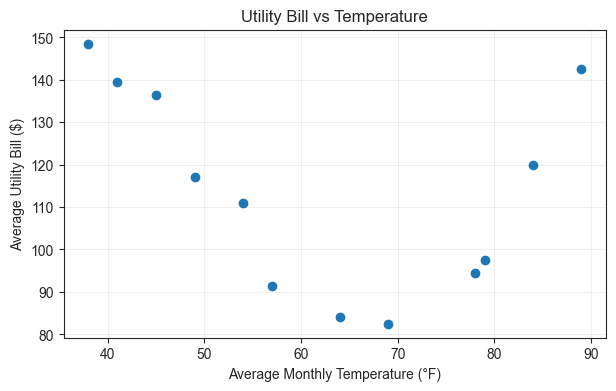

In [6]:
# Create scatter plot of average bill vs average monthly temperature
plt.scatter(utils_data['Average Monthly Temperature'], utils_data['Average Bill'])
plt.xlabel("Average Monthly Temperature (°F)")
plt.ylabel("Average Utility Bill ($)")
plt.title("Utility Bill vs Temperature")
plt.grid(True, alpha=0.3)

**(c) Have a look at the plot above. How would you describe the relationship between the variables?** 

In [ ]:
# The response variable should be "Average Bill" (the outcome we want to predict).
# The explanatory variable is "Average Monthly Temperature" (the average monthly temperature).
# There is a clear negative relationship: as temperature increases, the utility bill decreases.
# This makes intuitive sense - higher temperatures mean less need for heating,
# resulting in lower utility bills.

**(d) Train a simple linear regression model using scikit-learn**

In [7]:
# Prepare the data: define feature (X) and target (y)
# Note: X must be 2-dimensional, so we use double brackets
X = utils_data[['Average Monthly Temperature']]
y = utils_data['Average Bill']

# Create and train the linear regression model
model = LinearRegression()
model.fit(X, y)

# Print confirmation
print("Linear regression model has been trained successfully!")

Linear regression model has been trained successfully!


**(e) Calculate and interpret the value of $R^2$.**  

In [ ]:
# Make predictions using the trained model
y_pred = model.predict(X)

# Calculate R-squared value
r2 = r2_score(y, y_pred)
print(f"R-squared value: {r2:.4f}")

# Interpretation: The R-squared tells us what proportion of variance in the target
# variable is explained by the feature(s). The R-squared value above shows what
# percentage of the variation in utility bills can be explained by temperature.
# A higher R-squared value indicates a stronger linear relationship and suggests
# that temperature is a good predictor for utility bills.

R-squared value: 0.1241


**(f) Print the intercept and slope/coefficient and interpret them in terms a home owner would understand.**

In [ ]:
# Extract the intercept and slope from the model
intercept = model.intercept_
slope = model.coef_[0]

print(f"Intercept: ${intercept:.2f}")
print(f"Slope: ${slope:.2f} per degree Fahrenheit")

# Interpretation for a homeowner:
# The intercept represents the expected utility bill when the average monthly temperature 
# is 0°F (though this is outside the typical range of data).
# The slope means that for every 1 degree increase in average monthly temperature,
# the utility bill is expected to change by the slope amount. 
# A negative slope indicates that as temperature increases, the utility bill decreases,
# which reflects the fact that warmer months require less heating, resulting in lower utility costs.

Intercept: $143.62
Slope: $-0.48 per degree Fahrenheit


**(g) Use your fitted model to estimate the average utility bill if the average monthly temperature is 120 degrees. Do you think that your answer is reasonable? Why or why not?** 

In [11]:
# Create a new observation with average monthly temperature of 120°F
new_temp = pd.DataFrame({'Average Monthly Temperature': [120]})

# Make prediction using the trained model
predicted_bill = model.predict(new_temp)[0]
print(f"Predicted utility bill at 120°F: ${predicted_bill:.2f}")

# Evaluation of reasonableness:
# This prediction is NOT reasonable because we are extrapolating far outside the range
# of the data we used to train the model. A temperature of 120°F average is unrealistic
# for typical climates - most locations have average monthly temperatures that don't
# exceed 90-100°F. The model was trained on observed data within a specific range,
# and using it to predict beyond that range (especially at such an extreme value)
# can lead to meaningless results. The prediction could even be negative, which is
# impossible for a utility bill.

# Check the range of temperatures in our data
print(f"\nTemperature range in data: {utils_data['Average Monthly Temperature'].min():.1f}°F to {utils_data['Average Monthly Temperature'].max():.1f}°F")
print(f"We are predicting at {new_temp['Average Monthly Temperature'][0]}°F, which is beyond our data range!")

Predicted utility bill at 120°F: $86.04

Temperature range in data: 38.0°F to 89.0°F
We are predicting at 120°F, which is beyond our data range!
